1. Загрузите выборку из файла gbm-data.csv с помощью pandas и преобразуйте ее в массив numpy (параметр values у датафрейма). В первой колонке файла с данными записано, была или нет реакция.
Все остальные колонки (d1 - d1776) содержат различные характеристики молекулы, такие как размер, форма и т.д. Разбейте выборку на обучающую и тестовую, используя функцию train_test_split с
параметрами test_size = 0.8 и random_state = 241.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import log_loss

df = pd.read_csv('gbm-data.csv')
data = df.values
y = data[:, 0]
X = data[:, 1:]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=241)

2.Обучите GradientBoostingClassifier с параметрами n_estimators=250,
verbose=True, random_state=241 и для каждого значения learning_rate
из списка [1, 0.5, 0.3, 0.2, 0.1] проделайте следующее:

• Используйте метод staged_decision_function для предсказания качества на обучающей и тестовой выборке на каждой
итерации.

• Преобразуйте полученное предсказание по формуле 1\(1+e^(−y_pred)) ,
где y_pred — предсказанное значение.

• Вычислите и постройте график значений log-loss на обучающей и тестовой выборках, а также найдите минимальное значение метрики и номер итерации, на которой оно достигается.


learning_rate=1: min test log-loss = 0.582294 at iteration 1
learning_rate=0.5: min test log-loss = 0.558458 at iteration 5
learning_rate=0.3: min test log-loss = 0.542590 at iteration 19
learning_rate=0.2: min test log-loss = 0.530519 at iteration 37
learning_rate=0.1: min test log-loss = 0.526064 at iteration 52


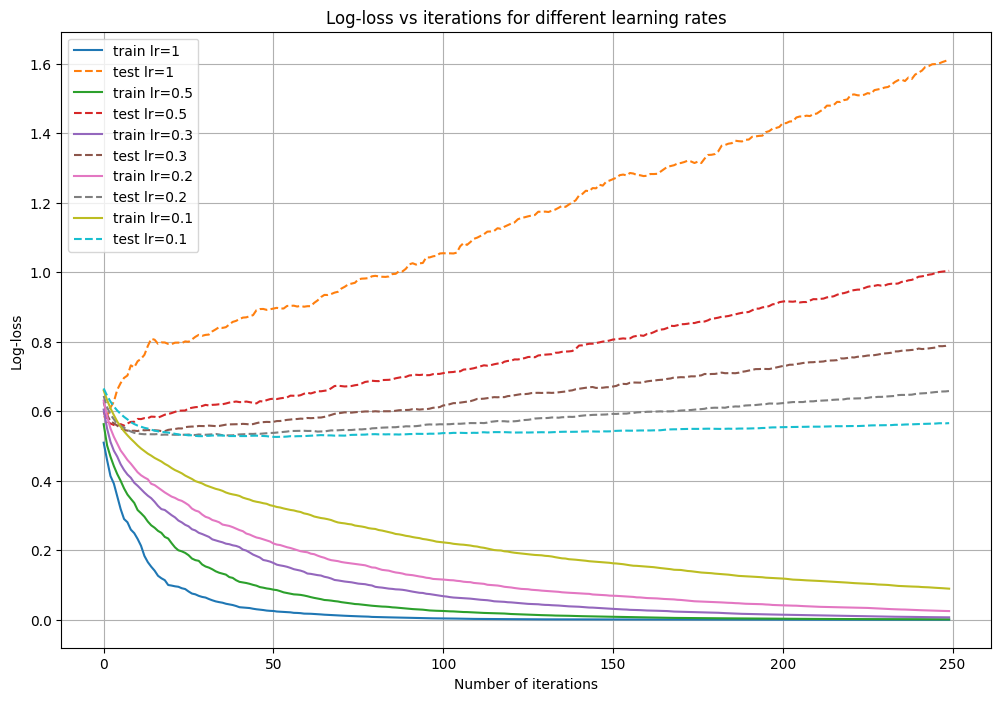

In [6]:
learning_rates = [1, 0.5, 0.3, 0.2, 0.1]
n_estimators = 250
results = {}
plt.figure(figsize=(12, 8))

for lr in learning_rates:
    clf = GradientBoostingClassifier(n_estimators=n_estimators,
                                     learning_rate=lr,
                                     random_state=241)
    clf.fit(X_train, y_train)
    train_pred = clf.staged_decision_function(X_train)
    test_pred = clf.staged_decision_function(X_test)

    train_proba = [1 / (1 + np.exp(-y_pred)) for y_pred in train_pred]
    test_proba  = [1 / (1 + np.exp(-y_pred)) for y_pred in test_pred]

    train_loss = [log_loss(y_train, proba) for proba in train_proba]
    test_loss  = [log_loss(y_test, proba) for proba in test_proba]

    min_test_loss = min(test_loss)
    best_iter = np.argmin(test_loss) + 1
    results[lr] = (min_test_loss, best_iter)

    plt.plot(train_loss, label=f'train lr={lr}')
    plt.plot(test_loss, label=f'test lr={lr}', linestyle='--')

    print(f"learning_rate={lr}: min test log-loss = {min_test_loss:.6f} at iteration {best_iter}")

plt.xlabel('Number of iterations')
plt.ylabel('Log-loss')
plt.title('Log-loss vs iterations for different learning rates')
plt.legend()
plt.grid(True)
plt.show()

3. Как можно охарактеризовать график качества на тестовой выборке, начиная с некоторой итерации: переобучение (overfitting) или
недообучение (underfitting)? В ответе укажите одно из слов overfitting
либо underfitting.


In [3]:
print('Overfitting')

Overfitting


4. Приведите минимальное значение log-loss на тестовой выборке и
номер итерации, на котором оно достигается, при learning_rate =
0.2.

In [4]:
lr_target = 0.2
min_test_loss_lr02, best_iter_lr02 = results[lr_target]
print(f"log-loss = {min_test_loss_lr02:.2f}")
print(f"Номер итерации = {best_iter_lr02}")

log-loss = 0.53
Номер итерации = 37


5. На этих же данных обучите RandomForestClassifier с количеством
деревьев, равным количеству итераций, на котором достигается
наилучшее качество у градиентного бустинга из предыдущего пункта, random_state=241 и остальными параметрами по умолчанию.
Какое значение log-loss на тесте получается у этого случайного леса? (Не забывайте, что предсказания нужно получать с помощью
функции predict_proba. В данном случае брать сигмоиду от оценки
вероятности класса не нужно)


In [5]:
n_estimators_rf = best_iter_lr02
rf = RandomForestClassifier(n_estimators=n_estimators_rf, random_state=241, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_proba = rf.predict_proba(X_test)[:, 1]
test_logloss_rf = log_loss(y_test, y_pred_proba)

print(f"\nСлучайный лес с {n_estimators_rf} деревьями")
print(f"Log-loss  = {test_logloss_rf:.2f}")
with open('result13.txt','w',encoding='utf-8') as f:
    f.write('overfitting')
    f.write(f"\n{min_test_loss_lr02:.2f}\n{best_iter_lr02}\n{test_logloss_rf:.2f}")


Случайный лес с 37 деревьями
Log-loss  = 0.54
